#**CHAPTER 2.SCHEMA FIRST PROMPTING FOR CREDIT MEMOS**
---

##REFERENCE

https://chatgpt.com/share/699b0038-c410-8012-86f8-5f0486194095

##0.CONTEXT

####0.1.OVERVIEW



As a financial analyst presenting to the Board of Directors, the standard we must meet is not “a memo that sounds confident.” The standard is a work product that is defensible under institutional scrutiny: bounded by the evidence we actually have, explicit about what we do not have, transparent about which judgments are assumptions rather than facts, and auditable in a way that enables independent review. This notebook is designed to demonstrate that posture. It is not an attempt to automate credit approval, and it is not a claim that a language model can replace underwriting judgment. It is a controlled demonstration of how a language model can be used as a drafting component inside a governance pipeline—one that produces reviewable artifacts, enforces structure, and fails closed into human oversight when controls are not satisfied.

The specific use case is a first-pass credit analysis memorandum for Northbridge Components, Inc. (Case ID: SYN-IC-0002), an industrial components manufacturer with 185 million of last fiscal year revenue and 27 million of EBITDA. The synthetic packet includes core credit profile metrics (total debt to EBITDA of 4.2x, interest coverage of 2.6x, liquidity of $18.0 million), a covenant framework (maximum total leverage stepping down from 4.75x to 4.25x and a minimum interest coverage of 2.25x), and qualitative risk factors (customer concentration, cyclicality linked to industrial capex, and raw material cost volatility), with mitigants described at a high level (long-term agreements, a hedging program described but not quantified, and historically stable maintenance capex). The packet also includes explicit non-goals that matter to governance: the model must not invent pricing, ratings, market comparables, or external evidence that is not in the packet. The objective is to draft something suitable for investment committee discussion as a first-pass note, while making clear the boundaries of what is known and what remains unverified.

The Board should understand the notebook’s intent through a simple institutional lens: we are converting “prompting” from an informal technique into a controlled lifecycle. In many organizations, a language model is used like an unaccountable author: a person pastes some context, gets a fluent memo back, and then forwards it onward because it “looks right.” That workflow is risky precisely because it lacks traceability. It is unclear what the model relied on, unclear which statements are evidence versus inference, unclear what is missing, and unclear whether the memo is complete enough to present. This notebook implements the opposite posture. It treats prompts and outputs as first-class artifacts with IDs, versions, timestamps, hashes, and validation outcomes. It treats the “final output” of the system not as the memo itself, but as a governed decision about whether the memo can be promoted under controls. And it produces a reproducibility bundle—run manifest, prompt logs, prompt trace, risk log, and final report—so an independent reviewer can see what happened without trusting the operator’s narrative.

The mechanism is intentionally straightforward and board-friendly. The notebook runs the same drafting task twice, using two different prompt versions. Version 1 (v1) is a free-form prompt that asks the model to write a readable investment committee memo in prose. This is what many teams do today. It produces something a human can read and discuss, and it can be valuable in accelerating drafting and summarization. But free-form output has a structural weakness: it is not machine-checkable. The model can intermix facts, assumptions, and open diligence items in ways that are hard to separate reliably. The output may be coherent but still unsafe, because the reader cannot quickly distinguish what was given versus what was inferred. Version 2 (v2) addresses that weakness by using schema-first output. Instead of asking for prose, we ask for a single JSON object that must conform to a strict schema contract. That schema requires explicit fields: **facts_provided**, **assumptions_introduced**, **open_items**, **analysis**, **draft_output**, and **verification_status**, where verification_status must be exactly “Not verified.” This is not a stylistic preference; it is a governance control. It forces disclosure and enables deterministic validation.

The report generated by the notebook in this run makes the distinction concrete. v1 produced a coherent, readable first-pass memo that covered the major elements in plain language: company overview, financial profile, key risks, mitigants, covenant framing, and liquidity assessment. In human terms, the memo “made sense.” However, v1 failed Gate A, the free-form reviewability gate, because it did not contain explicit, machine-checkable markers separating facts, assumptions, and open items. In other words, the memo might be usable for a human discussion, but it is not suitable for automated downstream controls or consistent institutional review without manual extraction and interpretation. v2, by contrast, passed Gate B, schema compliance. The v2 output parsed successfully as balanced JSON (with extraction due to minor wrapper drift) and validated against the schema: all required keys were present, no extra keys were allowed, and verification_status was explicitly set to “Not verified.” The v2 output also quantified the separation that governance requires: 8 facts, 4 assumptions, and 8 open items. That is the key institutional benefit. The substance of the credit judgment did not change; the accountability and auditability did.

At this point, the Board might ask: if v2 is more structured and passed schema compliance, why is the promotion recommendation still **HUMAN_REVIEW**? This is the most important governance message of the notebook. HUMAN_REVIEW is not “the model failed.” HUMAN_REVIEW is the intended state in a controlled drafting pipeline when material diligence items remain unresolved. The notebook is designed to avoid false certainty. It can produce a first-pass memo that is useful for committee discussion, but it cannot—and should not—promote that memo to a credit decision if key data is missing. In this run, both v1 and v2 converged on the same promotion recommendation because the underlying packet does not provide key underwriting inputs. The v2 schema-first output made those gaps explicit and enumerated them as open items. The system’s decision is therefore conservative and institutionally appropriate: proceed to investment committee discussion as a draft, but with explicit caveats and a diligence checklist, not as a “ready-to-approve” product.

This is why we emphasize that the notebook’s “result” is not primarily the memo text. The result is the governed package: the final report and the evidence bundle that explains how we got there. In a board setting, that distinction is crucial. If we were simply trying to generate prose, we could do so without any of these controls. The reason we are doing this work is that we need AI outputs that can be incorporated into professional processes without undermining accountability. A memo that is fluent but untraceable is risky. A memo that is explicit about facts, assumptions, and open items, and that is accompanied by a traceable audit trail, is materially safer. In finance, the ability to show the work—and to show where the work is incomplete—is often more valuable than the ability to produce a polished narrative quickly.

The notebook’s gates and controls are designed to reflect that institutional logic. Gate A evaluates whether free-form output is reviewable without ambiguity. It is deliberately conservative: it looks for markers that demonstrate separation of evidence and inference. v1 failed this gate because the output was prose-only. Gate B evaluates schema compliance: can we parse the output as valid JSON, does it match the schema, and does it include all required fields, including “Not verified.” v2 passed this gate. Gate C evaluates promotion readiness: is the work product sufficiently complete to be presented as a first-pass memo, and does it clearly disclose what remains missing. Gate C does not ask the model to decide the loan; it asks whether the memo is appropriate to advance to a human committee for discussion. In this run, Gate C resulted in a conditional pass into HUMAN_REVIEW because eight open items were identified as critical to resolve before any final decision. In a governance-first framework, this is exactly the behavior we want: the system accelerates drafting and organizes diligence, but it refuses to launder missing facts into implied certainty.

The Board should also recognize why schema-first structure is not merely a technical preference but a risk control. When a memo is in JSON with explicit fields, downstream systems can validate completeness and apply consistent policies. For example, an organization can require that open_items must never be empty for first-pass drafts, or that assumptions_introduced must be non-empty if the analysis contains uncertainty language, or that verification_status must always be “Not verified” until a separate verification workflow is completed. Those controls are hard to apply consistently to free-form text. Schema-first output makes them enforceable. It also supports regression testing and change management. Because prompts are versioned and hashed, and outputs are logged with hashes and timestamps, we can test whether a new prompt version improves compliance metrics (schema validity, boundary compliance, assumption leak rates) without relying on subjective impressions. For a board, that is a crucial move: from “we think it’s better” to “we can measure that it is safer.”

The report also highlights an operational reality that boards should appreciate: models can follow instructions imperfectly, especially around formatting. Even when asked for JSON only, a model may wrap output in code fences, add a preamble, or produce too much text and get truncated. The notebook treats that reality as a design constraint rather than a surprise. It includes parsing and validation controls. In the run you reviewed, v2 passed schema compliance, but the parsing step involved an extraction message (“OK (extracted)”), meaning the output contained wrapper drift but still held a complete balanced object that could be recovered and validated. That is an important institutional lesson. Real-world production workflows must assume and handle wrapper drift. The point is not to pretend drift will never happen. The point is to detect it, normalize it under controlled conditions, and escalate if normalization fails.

Equally important is what the notebook does not do. It does not verify truth, it does not consult external sources, and it does not ingest real loan documents or market data with provenance controls. It does not compute pro forma leverage, cash flow stress cases, or covenant headroom deterministically. It does not evaluate whether the assumptions listed (for example, about hedging effectiveness or liquidity adequacy) are correct, because the packet does not provide the evidence required to verify them. It also does not implement a human sign-off workflow, a committee approval registry, or immutable artifact storage. These limitations are not defects in the notebook; they are boundaries of scope. The notebook is the second step in a curriculum: it is about schema-first prompting as a control, not about full underwriting automation. In institutional deployment, we would layer additional controls and data connectors on top of this foundation.

Seen in that light, this notebook is relevant to board oversight because it demonstrates a pattern: “capability without controls is risk; controls turn capability into usable institutional tooling.” Here, the capability is rapid drafting and summarization. The control is schema-first output with strict validation and explicit uncertainty disclosure. The governed outcome is not an approval decision; it is a structured memo artifact and an escalation recommendation that directs human attention to what is missing. This is aligned with how committees actually work: committees do not need a model to decide; committees need a structured brief that makes trade-offs and diligence gaps visible.

Finally, the notebook is deliberately designed to be extensible. Notebook 2 is an early building block in a broader prompt engineering sequence. Once schema-first output is established, future chapters can expand the governance envelope in predictable ways. Context packing will formalize what evidence is included versus excluded and will record inclusion decisions and rationales. Multi-pass prompting will separate drafting from critique and revision to reduce error rates without deploying agents. Prompt hardening and evaluation will introduce red-team tests and regression-safe promotion so that prompts are only promoted when metrics improve and critical failure rates do not regress. In other words, this notebook establishes the first control surface. The following chapters widen the control surface until the workflow becomes institution-ready: evidence selection, multi-pass refinement, adversarial testing, and committee governance integration.

The Board-facing interpretation is therefore clear and conservative. We are not asking the Board to trust an LLM. We are showing the Board a controlled process that uses an LLM as a bounded component. The system’s outputs are auditable; the system’s failures are logged; the system’s uncertainties are explicit; and the system’s promotion decisions default to human oversight when completeness or compliance is insufficient. The report you reviewed demonstrates that posture in practice: v1 produced readable prose but failed machine-checkable reviewability; v2 preserved the same substantive judgment but made it auditable and structurally compliant; and both versions concluded with the appropriate institutional recommendation: HUMAN_REVIEW pending resolution of eight critical open items. That is the governance-first definition of success: not “perfect certainty,” but “defensible acceleration under control.”

###0.2.MAIN DIFFERENCES WITH CHAPTER 1


**Chapter 1** established that the **prompt itself is a governance** artifact. By converting a vague instruction into a contract — with an explicit role, a bounded evidence packet, refusal rules, and a declared output schema — we moved from "ask the model something" to "specify what the model is permitted to do." That discipline matters because an undisciplined prompt is an open invitation for the model to fill gaps with plausible-sounding invention. **Constraining the input side of the interaction is the first control surface, and it is a necessary one**. But Chapter 1 also revealed its own limitation: a well-written contract prompt does not guarantee a machine-checkable output. The model can read the contract, understand it, and still respond in fluent prose that blends facts, assumptions, and inferences without separating them. **The output looks right. It may even be right. But it cannot be validated programmatically, which means it cannot be governed consistently at scale.**

**Chapter 2** addresses exactly that gap. The shift is not from bad prompts to better prompts — it is from human-readable output to machine-enforceable output. **Schema-first prompting requires the model to return a single JSON object conforming to a strict contract: enumerated facts, explicit assumptions, declared open items, and a mandatory verification status of "Not verified."** This structure is not cosmetic. It is what makes downstream validation deterministic. When the output is a governed JSON object, a pipeline can check — without human interpretation — whether facts and assumptions are separated, whether the uncertainty disclosure is present, and whether any numbers in the output were introduced that did not exist in the input packet. None of those checks are possible against free-form prose, no matter how disciplined the prompt that produced it.

**The practical consequence is that prompt discipline and output enforcement are complementary controls**, not alternatives. Prompt discipline reduces the probability that the model will misbehave. Output enforcement catches the cases where it does, and makes the catching auditable. A pipeline that has only one of the two is incomplete: tight prompts with unvalidated outputs still produce ungoverned artifacts, and strict output schemas applied to poorly scoped prompts produce structured noise. Chapter 2 is where both controls are active simultaneously, and that combination is what makes the pipeline defensible.

**Chapter 2 refines the gate architecture** inherited from Chapter 1 in three precise ways. The first change is gate path separation: rather than routing both prompt versions through identical schema gates, Chapter 2 assigns each version its own evaluation function. The free-form v1 output is assessed for the presence of disclosure markers — facts, assumptions, open items, verification status — which is the appropriate standard for prose. The schema-first v2 output is assessed against the full JSON contract. This distinction matters because applying a schema gate to intentional prose will always produce a false failure, generating noise that obscures genuine control violations.

**The second change replaces Chapter 1's named-marker boundary check — a fixed list of forbidden words like "bloomberg" or "wacc" — with a numerical boundary check**. Chapter 2 extracts every number from the output and compares it against every number present in the input packet. Any value introduced by the model that did not exist in the packet is flagged as an evidence boundary violation. This is mathematically grounded rather than heuristic, and it catches invented calculations regardless of how they are phrased.

**The third change adds an assumption leak detector** absent in Chapter 1. If the model uses uncertainty language anywhere in its output but leaves the assumptions field empty, the pipeline flags it as a medium-severity risk. Fluent confidence without declared assumptions is precisely the failure mode these notebooks are designed to prevent.

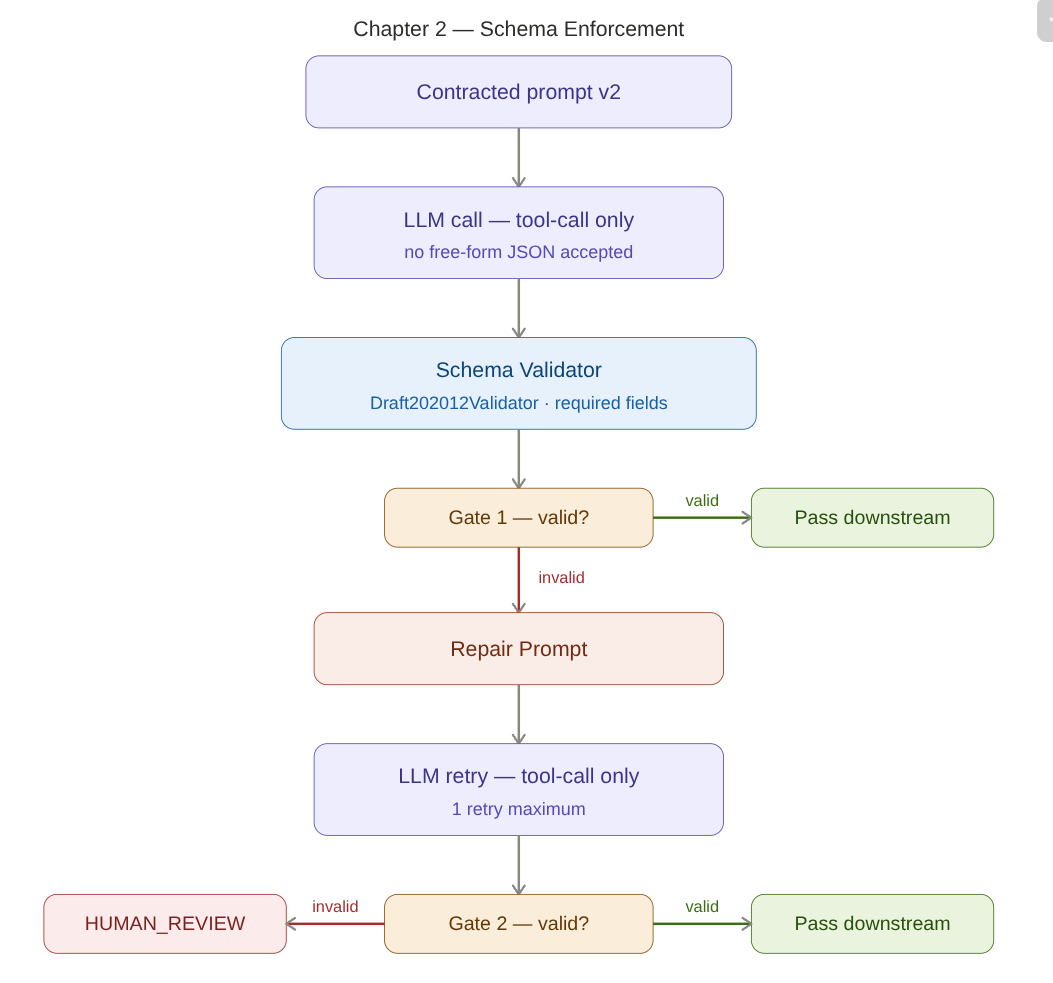

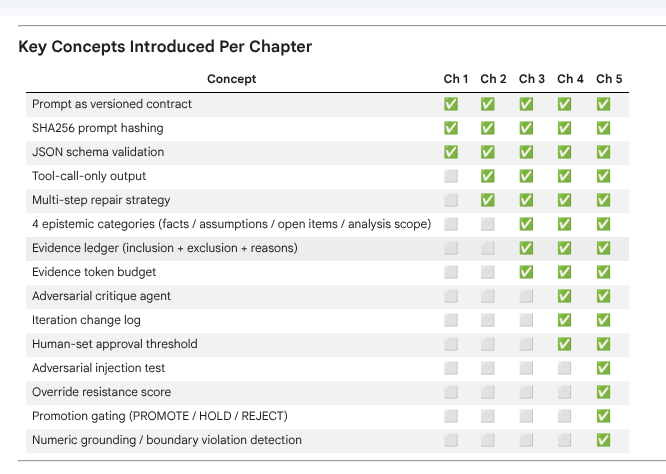

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Install, Imports, Determinism, and Directory Setup (Pedagogical Explanation)**

Cell 1 establishes the notebook as a controlled environment rather than an ad-hoc playground. The first objective is operational hygiene: installing required libraries (Anthropic SDK and jsonschema) and importing the standard modules needed for hashing, logging, timestamping, packaging, and deterministic behavior. The second objective is governance hygiene: ensuring every run produces artifacts in a predictable place. That is why the cell creates **artifacts/** and **deliverables/** directories early. Board relevance: reproducibility and evidence are non-negotiable in finance. A model output without a reproducibility trail is not defensible.

The determinism settings are also part of control-grade posture. Fixing **PYTHONHASHSEED** and **random.seed** does not “make the model deterministic” (LLM sampling can still introduce variability), but it *does* make the non-LLM parts deterministic: synthetic data generation, hashing consistency, and ordering of outputs. In controlled workflows, we reduce variability where we can, and we log the variability we cannot fully eliminate. The cell also defines a single canonical UTC timestamp function using `datetime.datetime.now(datetime.timezone.utc).isoformat()`. That matters because audit logs must be timezone consistent, especially when workflows are reviewed across teams and geographies.

In short: Cell 1 lays the foundation for a governed run. It ensures we can say: “Here is the environment, here is where evidence is stored, here is the deterministic baseline for everything except the model’s generation.” Without this cell, the rest of the notebook is just a demo; with this cell, it becomes a reproducible pipeline artifact.

In [ ]:
# Cell 1: Install + imports + deterministic settings + directory setup
!pip -q install anthropic jsonschema

import os, json, re, hashlib, random, zipfile, pathlib, datetime
from typing import Any, Dict, Tuple, List

# Determinism controls
os.environ["PYTHONHASHSEED"] = "1337"
random.seed(1337)

# Directories
BASE_DIR = pathlib.Path(".").resolve()
ARTIFACTS_DIR = BASE_DIR / "artifacts"
DELIVERABLES_DIR = BASE_DIR / "deliverables"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DELIVERABLES_DIR.mkdir(parents=True, exist_ok=True)

def utc_now_iso() -> str:
    return datetime.datetime.now(datetime.timezone.utc).isoformat()

print("Setup complete:", {"utc_now": utc_now_iso(), "base_dir": str(BASE_DIR)})

Setup complete: {'utc_now': '2026-04-03T19:01:27.800073+00:00', 'base_dir': '/content'}


##2.CONFIGURATION AND SCHEMA

###2.1.OVERVIEW

**Cell 2 — Configuration, Schemas, Hashing, Redaction, and Validation Helpers (Pedagogical Explanation)**

Cell 2 is the notebook’s control surface. It defines the model configuration (model name, temperature, token budget), and then it builds the compliance tools needed to treat the LLM as an auditable component rather than a source of “truth.” The most important element here is the **output schema**: a contract that says what the model must return. In Notebook 2, schema-first output is the core lesson: if we cannot validate the shape of the output, we cannot safely consume it downstream.

This cell defines the helper functions that enforce that posture. Hashing functions (SHA-256 over text and JSON) create stable fingerprints for prompts and outputs, supporting audit and regression testing. `write_json` and `append_jsonl` standardize how artifacts are written. Redaction functions ensure the audit log does not accidentally store secrets or PII-like strings. Risk logging turns failure states into structured events (severity, category, control, status) rather than vague print statements. That is board-relevant: governance is the difference between a “bad output” and a “documented control failure with escalation.”

Schema validation is also intentionally strict. The schema requires explicit separation of **facts_provided**, **assumptions_introduced**, and **open_items**, plus a mandatory **verification_status = "Not verified"**. That prevents the common finance failure mode where an LLM writes persuasive language that looks like certainty. By forcing uncertainty disclosure into a required field, we align the output format with the committee’s accountability needs.

In short: Cell 2 implements the core principle of this notebook. It converts “prompting” into “specification,” and it converts “LLM output” into “contract-validated evidence.” If schema checks fail, the pipeline does not pretend it succeeded; it escalates.

###2.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 2: Config + schemas + helpers (hashing, redaction, JSON writing, validation)
from jsonschema import validate as js_validate, ValidationError

MODEL_NAME = "claude-sonnet-4-6"
TEMPERATURE = 0.2
MAX_TOKENS = 900

RUN_ID = hashlib.sha256(f"{utc_now_iso()}|{MODEL_NAME}|{TEMPERATURE}|{MAX_TOKENS}|seed=1337".encode("utf-8")).hexdigest()[:16]

PATHS = {
    "run_manifest": ARTIFACTS_DIR / "run_manifest.json",
    "prompts_log": ARTIFACTS_DIR / "prompts_log.jsonl",
    "prompt_trace": ARTIFACTS_DIR / "prompt_trace.json",
    "risk_log": ARTIFACTS_DIR / "risk_log.json",
    "final_report": ARTIFACTS_DIR / "final_report.json",
}

def write_json(path: pathlib.Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def append_jsonl(path: pathlib.Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

def sha256_text(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def sha256_json(obj: Any) -> str:
    return sha256_text(json.dumps(obj, ensure_ascii=False, sort_keys=True))

_EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
_PHONE_RE = re.compile(r"\b(\+?\d[\d\-\s]{7,}\d)\b")
_APIKEY_HINT_RE = re.compile(r"(?i)(api[_\-\s]?key|secret|token)\s*[:=]\s*\S+")

def redact_text(s: str) -> str:
    s = _EMAIL_RE.sub("[REDACTED_EMAIL]", s)
    s = _PHONE_RE.sub("[REDACTED_PHONE]", s)
    s = _APIKEY_HINT_RE.sub("[REDACTED_SECRET]", s)
    return s

def extract_numbers(s: str) -> List[str]:
    return re.findall(r"(?<![A-Za-z])(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d+)?%?", s)

RISK_LOG: List[Dict[str, Any]] = []

def log_risk(severity: str, category: str, description: str, control: str, status: str = "OPEN") -> str:
    risk_id = hashlib.sha256(f"{RUN_ID}|{utc_now_iso()}|{severity}|{category}|{description}".encode("utf-8")).hexdigest()[:12]
    rec = {
        "risk_id": risk_id,
        "timestamp_utc": utc_now_iso(),
        "severity": severity,
        "category": category,
        "description": description,
        "control": control,
        "status": status,
    }
    RISK_LOG.append(rec)
    return risk_id

SCHEMA_OUTPUT_ID = "schema_first_v1"

OUTPUT_SCHEMA = {
    "$id": SCHEMA_OUTPUT_ID,
    "type": "object",
    "additionalProperties": False,
    "required": [
        "facts_provided",
        "assumptions_introduced",
        "open_items",
        "analysis",
        "draft_output",
        "verification_status",
    ],
    "properties": {
        "facts_provided": {"type": "array", "items": {"type": "string"}},
        "assumptions_introduced": {"type": "array", "items": {"type": "string"}},
        "open_items": {"type": "array", "items": {"type": "string"}},
        "analysis": {"type": "string"},
        "draft_output": {"type": "string"},
        "verification_status": {"type": "string", "enum": ["Not verified"]},
    },
}

def strict_validate_schema(obj: Any, schema: Dict[str, Any]) -> Tuple[bool, str]:
    if not isinstance(obj, dict):
        return False, "Output is not a JSON object."
    extra = set(obj.keys()) - set(schema["properties"].keys())
    if extra:
        return False, f"Extra fields not allowed: {sorted(list(extra))}"
    try:
        js_validate(instance=obj, schema=schema)
        return True, "OK"
    except ValidationError as e:
        return False, f"Schema validation error: {e.message}"

def ensure_required_fields(obj: Any) -> Tuple[bool, str]:
    if not isinstance(obj, dict):
        return False, "Not an object."
    required = set(OUTPUT_SCHEMA["required"])
    missing = sorted(list(required - set(obj.keys())))
    if missing:
        return False, f"Missing required fields: {missing}"
    if obj.get("verification_status") != "Not verified":
        return False, "verification_status must be exactly 'Not verified'."
    return True, "OK"

print("Config ready:", {"run_id": RUN_ID, "model": MODEL_NAME})

Config ready: {'run_id': '497f83b14e520c32', 'model': 'claude-sonnet-4-6'}


##3.SYNTHETIC MICRO CASE GENERATOR

###3.1.OVERVIEW

**Cell 3 — Deterministic Synthetic Micro-Case and Input Boundary Definition (Pedagogical Explanation)**

Cell 3 creates a synthetic investment-committee packet and explicitly declares the **input boundary**: what facts are permitted, and therefore what the model is allowed to use. This is not a toy detail. In institutional finance, the most dangerous failure mode is not a spelling mistake; it is a plausible-sounding statement that was never supported by evidence. The boundary is how we prevent “implicit sourcing.” If the packet does not contain pricing, comps, ratings, or forward projections, the model must not invent them.

The synthetic case is deliberately constrained: enough quantitative anchors to allow a credible first-pass memo (revenue, EBITDA, leverage, interest coverage, liquidity, covenants), but not enough to justify a final decision. That structure is pedagogical: it makes the open items list meaningful. A proper committee memo should say, “Here is what we know, here is what we are assuming, here is what we must verify.” Cell 3 sets up exactly that expectation.

The boundary object also gets hashed (SHA-256). That matters because it prevents subtle drift. If someone edits the packet or changes what is “allowed,” the boundary fingerprint changes. In real governance, those fingerprints can be stored in a registry so an auditor can prove which inputs were used to produce which memo.

In short: Cell 3 enforces a finance-grade discipline. It teaches that model output must be grounded in a packet, and that “missing facts” should become **open items**, not invented statements. This cell is where the notebook stops being a general AI demo and becomes a controlled experiment in governed drafting.

###3.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 3: Deterministic synthetic micro-case (Northbridge Components, Inc.) + input boundary definition

SYNTHETIC_CASE: Dict[str, Any] = {
    "case_id": "SYN-IC-0002",
    "company": "Northbridge Components, Inc.",
    "industry": "Industrial Components Manufacturing",
    "financials": {
        "revenue_last_fy_mm": 185.0,
        "ebitda_last_fy_mm": 27.0,
        "total_debt_to_ebitda": 4.2,
        "interest_coverage_ratio": 2.6,
        "liquidity_mm": 18.0,
    },
    "covenants": {
        "max_total_leverage": {
            "current_threshold": 4.75,
            "step_down_to": 4.25,
            "description": "Maximum total leverage stepping down from 4.75x to 4.25x per covenant schedule.",
        },
        "min_interest_coverage": {
            "threshold": 2.25,
            "description": "Minimum interest coverage ratio of 2.25x.",
        },
    },
    "qualitative_risk_factors": [
        "Customer concentration: revenue dependent on a limited number of industrial customers.",
        "Cyclicality: demand linked to industrial capex cycles, increasing earnings volatility.",
        "Raw material cost volatility: exposure to commodity input prices.",
    ],
    "mitigants": [
        "Long-term supply agreements with key customers reduce near-term revenue risk.",
        "Hedging program in place for raw material costs (scope and effectiveness not quantified in packet).",
        "Historically stable maintenance capex supports earnings quality.",
    ],
    "non_goals": [
        "Do not invent pricing, ratings, or market comparables not present in this packet.",
        "Do not invent forward projections or external analyst estimates.",
        "Do not cite external sources or benchmarks not provided here.",
    ],
    "memo_intent": "First-pass investment committee discussion note; not a final credit approval.",
}

# Input boundary: declares what the model is permitted to use
INPUT_BOUNDARY: Dict[str, Any] = {
    "boundary_id": "IB-SYN-IC-0002-v1",
    "description": "Permitted facts for model use are strictly limited to the SYNTHETIC_CASE packet above.",
    "permitted_keys": list(SYNTHETIC_CASE.keys()),
    "excluded": [
        "external market data",
        "credit ratings",
        "pricing / spread comparables",
        "forward financial projections",
        "analyst estimates",
        "sources not in packet",
    ],
}

# Boundary fingerprint — any edit to the packet changes this hash
BOUNDARY_SHA256 = sha256_json(SYNTHETIC_CASE)

# Both aliases defined — `case` used by Cells 5/6, `CASE` used by Cell 9
case = SYNTHETIC_CASE
CASE = SYNTHETIC_CASE  # ← this was the missing line

print("Cell 3 ready:", {
    "case_id": CASE["case_id"],
    "company": CASE["company"],
    "boundary_id": INPUT_BOUNDARY["boundary_id"],
    "boundary_sha256": BOUNDARY_SHA256,
})

Cell 3 ready: {'case_id': 'SYN-IC-0002', 'company': 'Northbridge Components, Inc.', 'boundary_id': 'IB-SYN-IC-0002-v1', 'boundary_sha256': 'a895887371e7edc4682c1e0b02a1574a85820de1c99b9decc9e5e4c7c5edcad7'}


##4.LLM CLIEN WRAPPER

###4.1.OVERVIEW

**Cell 4 — LLM Wrapper, Prompt Logging, Hashes, and Raw Response Persistence (Pedagogical Explanation)**

Cell 4 is the operational core: it is where we turn “call the model” into “call the model under audit.” Instead of directly invoking the API, we use a wrapper that enforces three principles: bounded configuration, traceability, and artifact generation. Bounded configuration means we cap temperature and token limits so the run is controlled and the sampling policy is logged. Traceability means every call is associated with a prompt ID, a version, an intent, and cryptographic hashes of the prompt and response. Artifact generation means we persist the raw response text for debugging and audit (without storing secrets), while keeping prompt logs redacted.

This design is board-relevant because it enables the question: “What exactly was asked, and what exactly was returned?” In production finance workflows, we cannot rely on screenshots or memory. We need an evidence trail. The wrapper writes an entry to **prompts_log.jsonl** that contains stable identifiers and hashes. This allows regression testing later: if we change the prompt, we can see exactly how outputs change and whether compliance improves.

Raw response persistence is especially important for Notebook 2 because schema-first output is brittle: even a code fence like ```json can break strict parsing, and truncation can produce malformed JSON. Storing raw responses allows us to diagnose whether failures come from wrapper text, truncation, or true schema noncompliance. Without raw capture, you only see “parse failed,” which is not actionable.

In short: Cell 4 is what makes the notebook operationally credible. It is the difference between “we ran a prompt” and “we ran a controlled, auditable LLM transaction that produced logs, hashes, and reproducible artifacts.”

###4.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 4: LLM client wrapper (Anthropic) + prompt logging (redacted + hashes) + RAW RESPONSE PERSISTENCE (AUDIT)

from google.colab import userdata
from anthropic import Anthropic

# --- Secrets ---
API_KEY = userdata.get("ANTHROPIC_API_KEY")
if not API_KEY or not isinstance(API_KEY, str) or len(API_KEY.strip()) < 10:
    raise RuntimeError("Missing ANTHROPIC_API_KEY in Colab Secrets. Set it via Colab Secrets.")

client = Anthropic(api_key=API_KEY.strip())

# --- Prompt/response hashing + IDs ---
def make_prompt_id(prompt_text: str) -> str:
    return sha256_text(prompt_text)[:16]

def log_prompt_event(event: Dict[str, Any]) -> None:
    # Store only redacted prompt text + hashes
    append_jsonl(PATHS["prompts_log"], event)

# --- Bounded model call ---
def call_claude(system_text: str, user_text: str, temperature: float, max_tokens: int) -> str:
    temperature = float(max(0.0, min(0.4, temperature)))
    max_tokens = int(max(200, min(1600, max_tokens)))

    msg = client.messages.create(
        model=MODEL_NAME,
        max_tokens=max_tokens,
        temperature=temperature,
        system=system_text,
        messages=[{"role": "user", "content": user_text}],
    )

    out_parts = []
    for block in msg.content:
        if getattr(block, "type", None) == "text":
            out_parts.append(block.text)
    return "\n".join(out_parts).strip()

# --- Main wrapper used by the notebook ---
def run_llm(prompt_bundle: Dict[str, Any]) -> Dict[str, Any]:
    # Build raw prompt text (for hashing only; redacted prompt stored in logs)
    system_text = prompt_bundle["prompt_components"]["system_policy"]
    user_text = prompt_bundle["prompt_components"]["user_task_spec"]
    raw_prompt_text = f"SYSTEM:\n{system_text}\n\nUSER:\n{user_text}"

    prompt_id = prompt_bundle["prompt_id"]
    prompt_sha = sha256_text(raw_prompt_text)
    redacted = redact_text(raw_prompt_text)

    started = utc_now_iso()
    response_text = call_claude(
        system_text=system_text,
        user_text=user_text,
        temperature=TEMPERATURE,
        max_tokens=MAX_TOKENS,
    )
    finished = utc_now_iso()

    response_sha = sha256_text(response_text)

    # --- AUDIT: persist raw response text (no secrets; safe to store) ---
    raw_dir = ARTIFACTS_DIR / "raw_responses"
    raw_dir.mkdir(parents=True, exist_ok=True)

    # Filename is deterministic within run; intent/version make it easy to locate
    raw_path = raw_dir / f"{RUN_ID}__{prompt_id}__{prompt_bundle['prompt_version']}__{prompt_bundle['prompt_intent']}.txt"
    with open(raw_path, "w", encoding="utf-8") as f:
        f.write(response_text)

    # --- Prompt log (redacted) ---
    log_prompt_event({
        "run_id": RUN_ID,
        "timestamp_utc": finished,
        "prompt_id": prompt_id,
        "prompt_version": prompt_bundle["prompt_version"],
        "prompt_intent": prompt_bundle["prompt_intent"],
        "output_schema_id": prompt_bundle.get("output_schema_id"),
        "prompt_sha256": prompt_sha,
        "response_sha256": response_sha,
        "redacted_prompt_text": redacted[:4000],
        "sampling": {"temperature": TEMPERATURE, "max_tokens": MAX_TOKENS},
        "timing": {"started_utc": started, "finished_utc": finished},
        "raw_response_path": str(raw_path),
    })

    return {
        "prompt_id": prompt_id,
        "prompt_version": prompt_bundle["prompt_version"],
        "prompt_intent": prompt_bundle["prompt_intent"],
        "output_schema_id": prompt_bundle.get("output_schema_id"),
        "response_text": response_text,
        "prompt_sha256": prompt_sha,
        "response_sha256": response_sha,
        "timestamp_utc": finished,
        "raw_response_path": str(raw_path),
    }

print("LLM wrapper ready (with raw response persistence):", {"model": MODEL_NAME, "temperature": TEMPERATURE, "max_tokens": MAX_TOKENS})

LLM wrapper ready (with raw response persistence): {'model': 'claude-sonnet-4-6', 'temperature': 0.2, 'max_tokens': 900}


##5.PROMPT ENGINE

###5.1.OVERVIEW

**Cell 5 — Prompt Engine: Free-Form v1 vs Schema-First v2, Plus Robust Parsing (Pedagogical Explanation)**

Cell 5 implements the central lesson of Notebook 2: outputs are safer when they are schema-first and machine-checkable. It defines two prompt builders. The free-form prompt (v1) produces narrative prose, which is readable but not mechanically verifiable. The schema-first prompt (v2) produces a strict JSON object that must contain required keys and must declare verification status as “Not verified.” This explicit compartmentalization is the institutional improvement: it makes it much harder for a model to hide assumptions inside fluent text.

This cell also addresses a practical reality: models often drift. They may wrap JSON in code fences, add a short preamble, or, if the response is long, truncate mid-field. Robust parsing is therefore a control function, not a convenience. A strict parser is the first line of defense; a governed extraction of the first balanced JSON object is the second line. Importantly, parsing improvements are not “loosening standards.” The standard remains: the final object must pass schema validation. The extraction merely recovers the object when the model adds wrappers.

Cell 5 also adds output-length controls inside the v2 prompt. This matters because unbounded memo text (especially inside a JSON string) is the most common reason JSON is malformed: truncation yields unbalanced quotes and braces. By explicitly bounding **analysis** and **draft_output** length, we reduce the probability of token-budget failures and increase the chance that the JSON object closes properly.

In short: Cell 5 is where prompt engineering becomes engineering. We stop thinking of prompts as “instructions” and start treating them as versioned specifications with bounded outputs and parsing-aware controls.

###5.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 5: Schema prompt engine (Notebook 2) — REQUIRED FUNCTIONS + OUTPUT-LENGTH CONTROLS + ROBUST PARSING

from typing import Any, Dict, Tuple

def build_freeform_prompt(case: Dict[str, Any]) -> Dict[str, Any]:
    system_policy = (
        "You are an assistant for finance practitioners. "
        "You must not invent facts, market data, external sources, pricing, ratings, or comparables. "
        "If information is missing, you must say it is missing and list it as questions to verify. "
        "Write in a board-ready, control-grade tone."
    )
    user_task = (
        "TASK: Draft a short investment committee memo for first-pass review.\n"
        "CONTEXT: Use ONLY the bounded packet below. Do not add external facts.\n"
        "OUTPUT: Free-form memo prose (no JSON required).\n\n"
        f"BOUNDED_PACKET(JSON):\n{json.dumps(case, ensure_ascii=False, indent=2)}\n"
    )
    raw_prompt_text = f"SYSTEM:\n{system_policy}\n\nUSER:\n{user_task}"
    pid = make_prompt_id(raw_prompt_text)
    return {
        "prompt_id": pid,
        "prompt_version": "v1",
        "prompt_intent": "draft_freeform",
        "output_schema_id": None,
        "prompt_components": {
            "system_policy": system_policy,
            "developer_constraints": [],
            "user_task_spec": user_task,
            "input_boundary": {"boundary_id": INPUT_BOUNDARY["boundary_id"], "boundary_sha256": BOUNDARY_SHA256},
            "output_schema": None,
            "stop_rules": [
                "No invented facts or market data.",
                "No external sources or citations.",
                "If missing info, list as questions to verify.",
            ],
        },
    }

def build_schema_prompt(case: Dict[str, Any], schema: Dict[str, Any]) -> Dict[str, Any]:
    system_policy = (
        "You are an assistant for finance practitioners producing machine-checkable outputs. "
        "You must not invent facts, market data, external sources, pricing, ratings, or comparables. "
        "If information is missing, you must list it in open_items. "
        "Return ONLY valid JSON with the exact required keys and no extra keys."
    )
    schema_contract = json.dumps(schema, ensure_ascii=False, indent=2)
    user_task = (
        "TASK: Produce a short investment committee memo for first-pass review.\n"
        "HARD CONSTRAINTS:\n"
        "- Use ONLY the bounded packet below.\n"
        "- Do NOT invent facts. Do NOT cite external sources.\n"
        "- If unknown, include it in open_items.\n"
        "- verification_status MUST be exactly: \"Not verified\".\n"
        "- Output MUST be a SINGLE JSON OBJECT ONLY.\n"
        "- NO markdown. NO backticks. NO code fences. NO preamble. NO epilogue.\n"
        "- JSON MUST start with '{' and end with '}'.\n"
        "- Keep fields concise to fit token budget:\n"
        "  * analysis <= 1200 characters\n"
        "  * draft_output <= 900 characters\n"
        "  * list fields: short bullet strings\n"
        "- If you are running long: shorten draft_output first. DO NOT truncate JSON.\n"
        "- Output MUST conform exactly to the schema below (no extra fields).\n\n"
        f"OUTPUT_SCHEMA(JSONSCHEMA):\n{schema_contract}\n\n"
        f"BOUNDED_PACKET(JSON):\n{json.dumps(case, ensure_ascii=False, indent=2)}\n"
    )
    raw_prompt_text = f"SYSTEM:\n{system_policy}\n\nUSER:\n{user_task}"
    pid = make_prompt_id(raw_prompt_text)
    return {
        "prompt_id": pid,
        "prompt_version": "v2",
        "prompt_intent": "draft_schema_first",
        "output_schema_id": schema.get("$id", SCHEMA_OUTPUT_ID),
        "prompt_components": {
            "system_policy": system_policy,
            "developer_constraints": [],
            "user_task_spec": user_task,
            "input_boundary": {"boundary_id": INPUT_BOUNDARY["boundary_id"], "boundary_sha256": BOUNDARY_SHA256},
            "output_schema": schema,
            "stop_rules": [
                "Return JSON only.",
                "No code fences / no markdown.",
                "No extra keys (additionalProperties=false).",
                "No invented facts; unknowns go to open_items.",
                "Keep analysis/draft_output within stated character limits.",
            ],
        },
    }

def _extract_first_balanced_json_object(s: str) -> Tuple[bool, str, str]:
    if not isinstance(s, str) or not s:
        return False, "", "Empty response."
    start = s.find("{")
    if start == -1:
        return False, "", "No '{' found."
    depth = 0
    in_str = False
    esc = False
    for i in range(start, len(s)):
        ch = s[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return True, s[start:i+1].strip(), "Extracted balanced JSON object."
    return False, "", "Unbalanced braces; could not extract complete JSON object."

def _parse_json_strict(s: str) -> Tuple[bool, Any, str]:
    s2 = (s or "").strip()

    # Stage 1: strict single-object parse (whitespace tolerated)
    if s2.startswith("{") and s2.endswith("}"):
        try:
            return True, json.loads(s2), "OK (strict)"
        except Exception as e:
            return False, None, f"Strict JSON parse error: {type(e).__name__}: {str(e)}"

    # Stage 2: governed extraction (handles code fences / preambles / trailing text)
    ok_ext, candidate, msg_ext = _extract_first_balanced_json_object(s2)
    if not ok_ext:
        return False, None, f"Non-JSON or format drift (not an object). Extraction failed: {msg_ext}"

    try:
        obj = json.loads(candidate)
        return True, obj, f"OK (extracted) — {msg_ext}"
    except Exception as e:
        return False, None, f"Extracted JSON parse error: {type(e).__name__}: {str(e)}"

def validate_or_escalate(output_obj: Any) -> Tuple[bool, str]:
    ok_schema, msg_schema = strict_validate_schema(output_obj, OUTPUT_SCHEMA)
    if not ok_schema:
        log_risk("HIGH", "schema_failure", msg_schema, "Gate A: strict schema validity", status="OPEN")
        return False, "HUMAN_REVIEW"

    ok_fields, msg_fields = ensure_required_fields(output_obj)
    if not ok_fields:
        log_risk("HIGH", "schema_failure", msg_fields, "Gate B: required fields + Not verified", status="OPEN")
        return False, "HUMAN_REVIEW"

    return True, "PROMOTE"

print("Cell 5 ready: v1 freeform + v2 schema-first prompt engine + robust JSON parse/extract + gates A/B.")

Cell 5 ready: v1 freeform + v2 schema-first prompt engine + robust JSON parse/extract + gates A/B.


##6.GATES

###6.1.OVERVIEW

**Cell 6 — Gates, Risk Detection, and Fail-Closed Escalation (Pedagogical Explanation)**

Cell 6 turns schema-first prompting into a governance workflow by defining gates and risk detectors. The gates embody the institutional posture: we do not “use” a model output unless it passes controls. Gate A checks schema validity; Gate B checks required fields and the “Not verified” disclosure; Gate C detects format drift (non-JSON, extra keys, wrapper text). If any gate fails, the notebook escalates to **HUMAN_REVIEW**. This fail-closed design is critical for board-facing credibility: the system is safer because it refuses to produce false certainty.

The cell also implements prompt-specific risk categories: schema_failure, format drift, boundary violations, assumption leaks. These risks are logged with severity, category, control, and status, producing a structured risk log that can be reviewed independently of the narrative memo. That is exactly how we want controls to behave in production: measurable, inspectable, and tied to explicit gates.

A practical improvement addressed here is repair logic. When parsing fails because the model wrapped output or truncated, a governed one-shot repair can rebuild compliant JSON—preferably by rebuilding from the bounded packet rather than “fixing” corrupted text. This is not a relaxation; it is controlled normalization with deterministic settings (temperature 0). If repair fails, we still escalate. The goal is to avoid operational brittleness while preserving strict promotion standards.

In short: Cell 6 is the notebook’s governance spine. It makes the difference between an LLM demo and a controlled pipeline: outputs must earn promotion by passing gates, and failures become logged risks that trigger human oversight.

###6.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 6: Gates + prompt-risk detection + escalation logic (repair = rebuild-from-packet, not from broken JSON)

from typing import List

def detect_instruction_conflict(prompt_bundle: Dict[str, Any]) -> List[str]:
    flags = []
    ut = prompt_bundle["prompt_components"]["user_task_spec"].lower()
    stops = " ".join(prompt_bundle["prompt_components"]["stop_rules"]).lower()
    if ("cite" in ut or "sources" in ut) and ("no external" in stops or "no external sources" in stops):
        flags.append("instruction_conflict")
    return flags

def detect_boundary_violations(output_obj: Dict[str, Any], case: Dict[str, Any]) -> List[str]:
    flags = []
    packet_text = json.dumps(case, ensure_ascii=False)
    packet_nums = set(extract_numbers(packet_text))
    out_text = json.dumps(output_obj, ensure_ascii=False)
    out_nums = set(extract_numbers(out_text))
    new_nums = sorted(list(out_nums - packet_nums))
    meaningful_new = [n for n in new_nums if n not in {"1","2","3","4","5","6","7","8","9","10"}]
    if meaningful_new:
        flags.append("evidence_boundary_violation")
        log_risk(
            "HIGH",
            "evidence_boundary_violation",
            f"Output introduced numbers not in packet: {meaningful_new[:12]}",
            "Gate C: boundary compliance heuristic (numbers)",
            status="OPEN",
        )
    return flags

def detect_assumption_leak(output_obj: Dict[str, Any]) -> List[str]:
    flags = []
    assumptions = output_obj.get("assumptions_introduced", [])
    combined = (output_obj.get("analysis","") + " " + output_obj.get("draft_output","")).lower()
    uncertainty_markers = ["likely", "estimate", "assume", "could", "approximately", "expected"]
    if isinstance(assumptions, list) and len(assumptions) == 0 and any(w in combined for w in uncertainty_markers):
        flags.append("assumption_leak")
        log_risk(
            "MEDIUM",
            "assumption_leak",
            "Uncertainty language detected but assumptions_introduced is empty.",
            "Gate B: facts vs assumptions separation",
            status="OPEN",
        )
    return flags

def gate_freeform_output(text: str) -> Tuple[str, List[str]]:
    flags = []
    t = (text or "").lower()
    if not any(k in t for k in ["facts", "assumptions", "open items", "questions to verify", "not verified"]):
        flags.append("verbosity_or_format_drift")
        log_risk(
            "MEDIUM",
            "verbosity_or_format_drift",
            "Free-form output lacks explicit facts/assumptions/open items markers; not machine-checkable.",
            "Gate A (freeform): reviewability markers",
            status="OPEN",
        )
    return ("HUMAN_REVIEW" if flags else "REVIEW_OK"), flags

def _repair_rebuild_from_packet(case: Dict[str, Any]) -> str:
    """
    Repair policy (governance-first):
      - Ignore malformed model output.
      - Rebuild a compliant JSON object directly from the bounded packet + schema contract.
      - Keep draft_output concise to avoid truncation.
    """
    repair_system = (
        "You are a strict JSON generator. "
        "Return ONLY one valid JSON object matching the provided JSON Schema exactly. "
        "No markdown, no code fences, no commentary. "
        "Do NOT invent facts. Unknowns must be in open_items. "
        "Keep analysis <= 900 chars and draft_output <= 600 chars."
    )
    repair_user = (
        "JSON_SCHEMA:\n"
        + json.dumps(OUTPUT_SCHEMA, ensure_ascii=False, indent=2)
        + "\n\nBOUNDED_PACKET:\n"
        + json.dumps(case, ensure_ascii=False, indent=2)
        + "\n\nOUTPUT RULES:\n"
          "- Output ONE JSON object only.\n"
          "- Include all required keys.\n"
          "- No extra keys.\n"
          "- verification_status must be \"Not verified\".\n"
          "- analysis <= 900 chars; draft_output <= 600 chars.\n"
          "- draft_output should be a concise committee memo (headline + 4 short sections).\n"
    )
    return call_claude(repair_system, repair_user, temperature=0.0, max_tokens=min(1200, max(700, MAX_TOKENS)))

def gate_schema_output(raw_text: str, case: Dict[str, Any]) -> Tuple[str, Dict[str, Any], Dict[str, Any]]:
    validation = {
        "attempt1_parse_ok": False,
        "attempt1_parse_msg": None,
        "attempt2_repair_used": False,
        "attempt2_parse_ok": False,
        "attempt2_parse_msg": None,
        "parse_ok": False,
        "parse_msg": None,
        "schema_ok": False,
        "schema_msg": None,
    }

    # Attempt 1: parse/extract
    ok1, obj1, msg1 = _parse_json_strict(raw_text)
    validation["attempt1_parse_ok"] = ok1
    validation["attempt1_parse_msg"] = msg1

    def _validate_obj(o: Dict[str, Any], parse_msg: str) -> Tuple[str, Dict[str, Any], Dict[str, Any]]:
        ok_schema, msg_schema = strict_validate_schema(o, OUTPUT_SCHEMA)
        validation["parse_ok"] = True
        validation["parse_msg"] = parse_msg
        validation["schema_ok"] = ok_schema
        validation["schema_msg"] = msg_schema

        ok_fields, msg_fields = ensure_required_fields(o)
        if not ok_schema or not ok_fields:
            log_risk("HIGH", "schema_failure", (msg_schema or msg_fields), "Gate A/B: schema + required fields", status="OPEN")
            return "HUMAN_REVIEW", o, validation

        rf = []
        rf += detect_boundary_violations(o, case)
        rf += detect_assumption_leak(o)
        if "evidence_boundary_violation" in rf:
            return "HUMAN_REVIEW", o, validation

        return "PROMOTE", o, validation

    if ok1 and isinstance(obj1, dict):
        return _validate_obj(obj1, msg1)

    # Attempt 2: repair = rebuild from packet (ignore broken JSON)
    validation["attempt2_repair_used"] = True
    log_risk("HIGH", "verbosity_or_format_drift", f"Initial parse failed: {msg1}", "Gate C: parse failure triggers rebuild repair", status="OPEN")

    repaired_text = _repair_rebuild_from_packet(case)
    ok2, obj2, msg2 = _parse_json_strict(repaired_text)
    validation["attempt2_parse_ok"] = ok2
    validation["attempt2_parse_msg"] = msg2

    if ok2 and isinstance(obj2, dict):
        return _validate_obj(obj2, msg2)

    # Fail-closed
    validation["parse_ok"] = False
    validation["parse_msg"] = f"Parse failed after rebuild repair. attempt1: {msg1} | attempt2: {msg2}"
    log_risk("HIGH", "verbosity_or_format_drift", validation["parse_msg"], "Fail-closed after rebuild repair", status="OPEN")
    return "HUMAN_REVIEW", {}, validation

print("Cell 6 updated: schema gate uses rebuild-from-packet repair (prevents unbalanced-brace failures due to truncation).")

Cell 6 updated: schema gate uses rebuild-from-packet repair (prevents unbalanced-brace failures due to truncation).


##7.PROMPT TRACE BUILDER

###7.1.OVERVIEW

**Cell 7 — Prompt Trace Builder (Lifecycle Evidence) (Pedagogical Explanation)**

Cell 7 produces **prompt_trace.json**, which is the lifecycle record of the prompt sequence. This is distinct from the final report: the trace is the forensic timeline. It captures for each prompt version: prompt_id, version, intent, inputs used, constraints applied, output schema id, validation outcomes, risk flags, and next action rationale. For Board-level governance, this is the most important artifact because it answers “what changed and why” in a way that can be audited.

In Notebook 2, the trace shape is intentionally simple: a 2-node sequence (v1 free-form → v2 schema-first). The trace makes the notebook pedagogically clear: v1 demonstrates why free-form is hard to validate; v2 demonstrates how schema-first enables machine checks and safer promotion. If v2 fails, the trace records that failure and the reason, preventing silent degradation.

The next_action_rationale field is especially important. It documents why v2 exists: to add constraints, enforce JSON output, and make separation of facts/assumptions/open items mandatory. In more advanced notebooks, traces become more complex (loops, multi-pass). Here, the trace is the foundation: every prompt becomes a first-class governed artifact, not a hidden string literal in code.

In short: Cell 7 is evidence engineering. It makes prompts reviewable, supports regression testing across prompt versions, and provides a committee-friendly narrative of “what we tried, what controls we applied, and what happened.”

###7.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 7: Prompt trace builder (artifacts/prompt_trace.json) + normalization
def build_prompt_trace(nodes: List[Dict[str, Any]]) -> Dict[str, Any]:
    # nodes: each must include prompt_bundle, llm_result, validation, risk_flags, next_action_rationale
    trace_nodes = []
    for n in nodes:
        pb = n["prompt_bundle"]
        llm = n.get("llm_result", {})
        trace_nodes.append({
            "prompt_id": pb["prompt_id"],
            "version": pb["prompt_version"],
            "intent": pb["prompt_intent"],
            "inputs_used": n.get("inputs_used", []),
            "constraints_applied": pb["prompt_components"]["stop_rules"],
            "output_schema_id": pb.get("output_schema_id"),
            "validation_outcome": n.get("validation_outcome", {}),
            "risk_flags": n.get("risk_flags", []),
            "next_action_rationale": n.get("next_action_rationale", ""),
            "prompt_sha256": llm.get("prompt_sha256"),
            "response_sha256": llm.get("response_sha256"),
            "timestamp_utc": llm.get("timestamp_utc"),
        })
    return {
        "run_id": RUN_ID,
        "timestamp_utc": utc_now_iso(),
        "prompt_sequence": trace_nodes,
        "shape": "sequence",
        "notes": "Notebook 2: free-form -> schema-first; promote only if schema-first passes strict controls.",
    }

print("Prompt trace builder ready.")

Prompt trace builder ready.


##8.REPORT COMPOSER

###8.1.OVERVIEW

**Cell 8 — Final Report Composer (Decision Artifact for Committees) (Pedagogical Explanation)**

Cell 8 composes **final_report.json**, the committee-facing decision artifact for the run. It aggregates baseline output (v1), schema output (v2), the deterministic differences summary, open items, risk summary, and the promotion recommendation. The aim is to provide a single, reviewable object that can be used in governance workflows: a committee can see what the model produced, whether it passed controls, and what diligence remains.

The differences summary is deterministic by design. Instead of subjective commentary, it reports concrete properties: whether v1 included machine-checkable markers, whether v2 passed schema validation, how many items were listed as facts/assumptions/open items, and what recommendation follows. This is important because it reduces the risk of “interpretive drift.” Committees should not need to infer whether an output is safe; the report should state it.

Cell 8 also enforces a schema for the final report itself. That is meta-governance: not only is the model output schema-first, but the system’s own decision artifact is also contract-validated. If the final report cannot be validated, the workflow should fail closed. That ensures we never produce a “half report” that looks official.

In short: Cell 8 is where the notebook becomes board-ready. It produces a single artifact that can be archived, reviewed, and compared across runs, and it converts model drafting into a controlled process with explicit promotion logic.

###8.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 8: Report composer (artifacts/final_report.json) with strict schema for notebook output
FINAL_REPORT_SCHEMA_ID = "final_report_schema_first_v1"

FINAL_REPORT_SCHEMA = {
    "$id": FINAL_REPORT_SCHEMA_ID,
    "type": "object",
    "additionalProperties": False,
    "required": [
        "run_id",
        "timestamp_utc",
        "case_id",
        "verification_status",
        "baseline_output",
        "schema_output",
        "differences_summary",
        "promotion_recommendation",
        "open_items",
        "risk_summary",
    ],
    "properties": {
        "run_id": {"type": "string"},
        "timestamp_utc": {"type": "string"},
        "case_id": {"type": "string"},
        "verification_status": {"type": "string", "enum": ["Not verified"]},
        "baseline_output": {"type": "string"},
        "schema_output": {"type": "object"},
        "differences_summary": {"type": "string"},
        "promotion_recommendation": {"type": "string", "enum": ["PROMOTE_SCHEMA_FIRST", "HUMAN_REVIEW"]},
        "open_items": {"type": "array", "items": {"type": "string"}},
        "risk_summary": {"type": "array", "items": {"type": "object"}},
    },
}

def deterministic_diff_summary(baseline_text: str, schema_obj: Dict[str, Any], schema_decision: str) -> str:
    # Deterministic comparisons: presence of required fields and machine-checkability
    has_markers = any(k in baseline_text.lower() for k in ["facts", "assumptions", "open items", "questions to verify", "not verified"])
    schema_fields = sorted(list(schema_obj.keys())) if isinstance(schema_obj, dict) else []
    lines = []
    lines.append(f"Baseline machine-checkable markers present: {bool(has_markers)}")
    lines.append(f"Schema-first decision: {schema_decision}")
    lines.append(f"Schema-first keys: {schema_fields}")
    # summarize counts deterministically
    if isinstance(schema_obj, dict):
        lines.append(f"facts_provided count: {len(schema_obj.get('facts_provided', [])) if isinstance(schema_obj.get('facts_provided', None), list) else 'N/A'}")
        lines.append(f"assumptions_introduced count: {len(schema_obj.get('assumptions_introduced', [])) if isinstance(schema_obj.get('assumptions_introduced', None), list) else 'N/A'}")
        lines.append(f"open_items count: {len(schema_obj.get('open_items', [])) if isinstance(schema_obj.get('open_items', None), list) else 'N/A'}")
    return "\n".join(lines)

def build_final_report(baseline_text: str, schema_obj: Dict[str, Any], schema_decision: str) -> Dict[str, Any]:
    open_items = []
    if isinstance(schema_obj, dict) and isinstance(schema_obj.get("open_items", None), list):
        open_items = schema_obj["open_items"]
    else:
        # If schema failed, use conservative open items set from packet non-goals + missing details
        open_items = [
            "Pricing / spread / fees for the term loan (not provided).",
            "Maturity, amortization profile, and collateral details (not provided).",
            "Covenant headroom calculations under downside scenarios (not provided).",
            "Recent interim performance and forward outlook (not provided).",
        ]

    promotion = "PROMOTE_SCHEMA_FIRST" if schema_decision == "PROMOTE" else "HUMAN_REVIEW"

    report = {
        "run_id": RUN_ID,
        "timestamp_utc": utc_now_iso(),
        "case_id": CASE["case_id"],
        "verification_status": "Not verified",
        "baseline_output": baseline_text,
        "schema_output": schema_obj if isinstance(schema_obj, dict) else {},
        "differences_summary": deterministic_diff_summary(baseline_text, schema_obj if isinstance(schema_obj, dict) else {}, schema_decision),
        "promotion_recommendation": promotion,
        "open_items": open_items,
        "risk_summary": RISK_LOG,
    }

    # Enforce final report schema; fail-closed if invalid
    try:
        js_validate(instance=report, schema=FINAL_REPORT_SCHEMA)
    except ValidationError as e:
        log_risk("HIGH", "schema_failure", f"final_report schema invalid: {e.message}", "Final report schema enforcement", status="OPEN")
        # Minimal fail-closed fallback
        report["promotion_recommendation"] = "HUMAN_REVIEW"
    return report

print("Final report composer ready.")

Final report composer ready.


##9.EXECUTION

###9.1.0VERVIEW

**Cell 9 — Run Orchestrator: Execute v1 and v2, Write Artifacts, Produce Decision (Pedagogical Explanation)**

Cell 9 is the operational pipeline execution. It runs the complete workflow end-to-end: it writes the run manifest, generates prompts for v1 and v2, calls the model through the audited wrapper, runs gates, builds the prompt trace, writes risk logs, and composes the final report. This is the “one button” execution that turns the notebook into a reproducible experiment. In production terms, Cell 9 resembles a job runner: it calls components in the right order and ensures artifacts are produced deterministically.

This cell matters for the Board because it demonstrates that governance is not a slide deck; it is a runnable system. The orchestrator shows how a firm can build an AI drafting capability that does not rely on individual analyst discretion. Instead, it uses explicit controls and stops safely when controls fail. If v2 fails to parse or validate, the orchestrator records the failure and yields a HUMAN_REVIEW recommendation. That is precisely the posture we want in institutional settings: escalation beats silent error.

Cell 9 also clarifies the difference between “LLM output” and “workflow output.” The workflow output is the final report and its recommendation, not the memo text. The memo is an input to human review; the pipeline’s job is to classify it as compliant or noncompliant and to preserve evidence.

In short: Cell 9 is the demonstration of a governed lifecycle: prompts as artifacts, outputs as contracts, and decisions as logged, reviewable events.

###9.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 9: Run orchestrator: executes pipeline end-to-end, writes artifacts
def write_run_manifest() -> Dict[str, Any]:
    manifest = {
        "run_id": RUN_ID,
        "timestamp_utc": utc_now_iso(),
        "model": MODEL_NAME,
        "sampling": {"temperature": TEMPERATURE, "max_tokens": MAX_TOKENS},
        "determinism": {"seed": 1337, "PYTHONHASHSEED": os.environ.get("PYTHONHASHSEED")},
        "input_boundary": {"boundary_id": INPUT_BOUNDARY["boundary_id"], "boundary_sha256": BOUNDARY_SHA256},
        "schema_ids": {"output_schema_id": SCHEMA_OUTPUT_ID, "final_report_schema_id": FINAL_REPORT_SCHEMA_ID},
        "case_id": CASE["case_id"],
    }
    write_json(PATHS["run_manifest"], manifest)
    return manifest

def run_pipeline() -> Dict[str, Any]:
    # 1) Free-form run
    pb1 = build_freeform_prompt(CASE)
    risk_flags_1 = detect_instruction_conflict(pb1)
    if risk_flags_1:
        log_risk("MEDIUM", "instruction_conflict", f"Prompt v1 conflict flags: {risk_flags_1}", "Static prompt linting", status="OPEN")

    llm1 = run_llm(pb1)
    baseline_text = llm1["response_text"]
    base_decision, base_flags = gate_freeform_output(baseline_text)

    # 2) Schema-first run
    pb2 = build_schema_prompt(CASE, OUTPUT_SCHEMA)
    risk_flags_2 = detect_instruction_conflict(pb2)
    if risk_flags_2:
        log_risk("MEDIUM", "instruction_conflict", f"Prompt v2 conflict flags: {risk_flags_2}", "Static prompt linting", status="OPEN")

    llm2 = run_llm(pb2)
    schema_decision, schema_obj, validation = gate_schema_output(llm2["response_text"], CASE)

    # Prompt trace (2-node sequence)
    nodes = [
        {
            "prompt_bundle": pb1,
            "llm_result": llm1,
            "inputs_used": ["BOUNDED_PACKET"],
            "validation_outcome": {"gate": "freeform_reviewability", "decision": base_decision},
            "risk_flags": base_flags,
            "next_action_rationale": "Move to schema-first prompt to enforce machine-checkable output contract and gates.",
        },
        {
            "prompt_bundle": pb2,
            "llm_result": llm2,
            "inputs_used": ["BOUNDED_PACKET", "OUTPUT_SCHEMA"],
            "validation_outcome": validation | {"decision": schema_decision},
            "risk_flags": [r["category"] for r in RISK_LOG],
            "next_action_rationale": "Terminate after schema-first evaluation; fail-closed to HUMAN_REVIEW on any control failure.",
        },
    ]
    prompt_trace = build_prompt_trace(nodes)
    write_json(PATHS["prompt_trace"], prompt_trace)

    # Final report
    final_report = build_final_report(baseline_text, schema_obj, schema_decision)

    # Write artifacts
    write_json(PATHS["risk_log"], RISK_LOG)
    write_json(PATHS["final_report"], final_report)

    return {
        "baseline_decision": base_decision,
        "schema_decision": schema_decision,
        "promotion_recommendation": final_report["promotion_recommendation"],
        "paths": {k: str(v) for k, v in PATHS.items()},
    }

manifest = write_run_manifest()
result = run_pipeline()
print("Pipeline complete:", json.dumps(result, indent=2))

Pipeline complete: {
  "baseline_decision": "HUMAN_REVIEW",
  "schema_decision": "HUMAN_REVIEW",
  "promotion_recommendation": "HUMAN_REVIEW",
  "paths": {
    "run_manifest": "/content/artifacts/run_manifest.json",
    "prompts_log": "/content/artifacts/prompts_log.jsonl",
    "prompt_trace": "/content/artifacts/prompt_trace.json",
    "risk_log": "/content/artifacts/risk_log.json",
    "final_report": "/content/artifacts/final_report.json"
  }
}


##10.AUDIT BUNDLE


###10.1.OVERVIEW

**Cell 10 — Packaging: Deliverables Zip + Minimal Console Summary (Pedagogical Explanation)**

Cell 10 packages the run outputs into **deliverables/deliverables.zip** and prints a minimal summary of what was produced. Packaging sounds mundane, but it is essential for governance. Reviewable systems must produce portable evidence bundles that can be shared with reviewers, archived, and attached to committee materials. A zip file containing manifests, logs, traces, and the final report is a practical approximation of what an enterprise artifact store would hold.

This cell enforces the idea that the “deliverable” of the notebook is not the console output. The deliverable is the artifact set: run_manifest, prompts_log, prompt_trace, risk_log, final_report, and the zip. That is how governance scales. Instead of relying on manual copying of text, the system produces consistent evidence.

The minimal console summary is also a control. It tells the operator exactly where the evidence lives and what files exist. In real environments, this would integrate with a registry, version control, or immutable storage. Here, it is enough to demonstrate the mechanism: the notebook produces an auditable bundle on every run.

In short: Cell 10 completes the institutional loop. It converts a notebook run into a portable review package that supports oversight. This is part of “capability increases require controls”: packaging is a control because it makes review and accountability feasible.

###10.2.CODE AND IMPLEMENTATION

####10.2.1.FILES

In [ ]:
# Cell 10: Packaging: zip deliverables + minimal console summary of outputs/paths
zip_path = DELIVERABLES_DIR / "deliverables.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in ARTIFACTS_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(BASE_DIR)))
# Ensure zip exists
assert zip_path.exists() and zip_path.stat().st_size > 0

# Minimal summary (paths only)
summary = {
    "run_id": RUN_ID,
    "timestamp_utc": utc_now_iso(),
    "artifacts_dir": str(ARTIFACTS_DIR),
    "deliverables_zip": str(zip_path),
    "files": sorted([str(p.relative_to(BASE_DIR)) for p in ARTIFACTS_DIR.rglob("*") if p.is_file()]),
}
print(json.dumps(summary, indent=2))

{
  "run_id": "497f83b14e520c32",
  "timestamp_utc": "2026-04-03T19:08:01.979527+00:00",
  "artifacts_dir": "/content/artifacts",
  "deliverables_zip": "/content/deliverables/deliverables.zip",
  "files": [
    "artifacts/final_report.json",
    "artifacts/prompt_trace.json",
    "artifacts/prompts_log.jsonl",
    "artifacts/raw_responses/497f83b14e520c32__41a5c3674ab1dba1__v1__draft_freeform.txt",
    "artifacts/raw_responses/497f83b14e520c32__4c42905e0fb53a28__v2__draft_schema_first.txt",
    "artifacts/risk_log.json",
    "artifacts/run_manifest.json"
  ]
}


####10.2.2.REPORT

In [ ]:
# Consolidated: Read Notebook 2 artifacts (right after Cell 9) + use Claude Haiku to write a normal-prose report + print it.
import json, pathlib, datetime, hashlib, re, textwrap
from typing import Any, Dict, Tuple, List
from google.colab import userdata
from anthropic import Anthropic

# ----------------------------
# Helpers (governed + deterministic)
# ----------------------------
def utc_now_iso() -> str:
    return datetime.datetime.now(datetime.timezone.utc).isoformat()

def sha256_text(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

_EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
_PHONE_RE = re.compile(r"\b(\+?\d[\d\-\s]{7,}\d)\b")
_APIKEY_HINT_RE = re.compile(r"(?i)(api[_\-\s]?key|secret|token)\s*[:=]\s*\S+")

def redact_text(s: str) -> str:
    s = _EMAIL_RE.sub("[REDACTED_EMAIL]", s)
    s = _PHONE_RE.sub("[REDACTED_PHONE]", s)
    s = _APIKEY_HINT_RE.sub("[REDACTED_SECRET]", s)
    return s

def safe_truncate(s: str, n: int) -> str:
    s = s or ""
    return s if len(s) <= n else s[:n] + "…[TRUNCATED]"

def write_text(path: pathlib.Path, s: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(s, encoding="utf-8")

def append_jsonl(path: pathlib.Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

# ----------------------------
# Load artifacts from Notebook 2 run (post Cell 9)
# ----------------------------
BASE = pathlib.Path(".").resolve()
A = BASE / "artifacts"
req = ["run_manifest.json", "prompt_trace.json", "risk_log.json", "final_report.json", "prompts_log.jsonl"]
missing = [f for f in req if not (A / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing artifacts: {missing}. "
        "Run Notebook 2 through Cell 9 first (Cell 9 writes these files)."
    )

run_manifest = json.loads((A / "run_manifest.json").read_text(encoding="utf-8"))
prompt_trace = json.loads((A / "prompt_trace.json").read_text(encoding="utf-8"))
risk_log = json.loads((A / "risk_log.json").read_text(encoding="utf-8"))
final_report = json.loads((A / "final_report.json").read_text(encoding="utf-8"))
prompts_log_path = A / "prompts_log.jsonl"

run_id = run_manifest.get("run_id", final_report.get("run_id", "UNKNOWN_RUN"))
model_name = run_manifest.get("model", "claude-haiku-4-5-20251001")

# ----------------------------
# Build an evidence summary (bounded, no leakage)
# ----------------------------
def summarize_risks(risks: List[Dict[str, Any]], max_items: int = 12) -> List[str]:
    out = []
    for r in (risks or [])[:max_items]:
        out.append(f"[{r.get('severity','?')}] {r.get('category','?')}: {r.get('description','')}")
    if risks and len(risks) > max_items:
        out.append(f"... plus {len(risks) - max_items} more risk items.")
    return out

def summarize_prompt_sequence(trace: Dict[str, Any]) -> List[str]:
    seq = trace.get("prompt_sequence", []) or []
    lines = []
    for i, n in enumerate(seq, 1):
        lines.append(
            f"{i}) {n.get('version','?')} | intent={n.get('intent','?')} | "
            f"schema={n.get('output_schema_id')} | "
            f"validation={n.get('validation_outcome', {})}"
        )
    return lines

evidence = {
    "run_meta": {
        "run_id": run_id,
        "timestamp_utc": run_manifest.get("timestamp_utc"),
        "model": model_name,
        "sampling": run_manifest.get("sampling"),
        "determinism": run_manifest.get("determinism"),
    },
    "notebook2_outputs": {
        "promotion_recommendation": final_report.get("promotion_recommendation"),
        "differences_summary": final_report.get("differences_summary"),
        "open_items": final_report.get("open_items", []),
        "baseline_output_excerpt": safe_truncate(final_report.get("baseline_output", ""), 1400),
        "schema_output_obj": final_report.get("schema_output", {}),
    },
    "prompt_sequence_summary": summarize_prompt_sequence(prompt_trace),
    "risk_summary": summarize_risks(risk_log),
}

# ----------------------------
# LLM call (Claude Haiku) to generate readable normal-prose report
# ----------------------------
API_KEY = userdata.get("ANTHROPIC_API_KEY")
if not API_KEY or not isinstance(API_KEY, str) or len(API_KEY.strip()) < 10:
    raise RuntimeError("Missing ANTHROPIC_API_KEY in Colab Secrets.")

client = Anthropic(api_key=API_KEY.strip())

def call_claude(system_text: str, user_text: str, temperature: float = 0.2, max_tokens: int = 1400) -> str:
    temperature = float(max(0.0, min(0.4, temperature)))
    max_tokens = int(max(400, min(1800, max_tokens)))
    msg = client.messages.create(
        model=model_name,
        max_tokens=max_tokens,
        temperature=temperature,
        system=system_text,
        messages=[{"role": "user", "content": user_text}],
    )
    parts = []
    for b in msg.content:
        if getattr(b, "type", None) == "text":
            parts.append(b.text)
    return "\n".join(parts).strip()

system_policy = (
    "You are writing a board-ready report for MBA / Master of Finance / practitioner audiences. "
    "Use ONLY the evidence provided. Do NOT invent facts, market data, pricing, ratings, comps, or sources. "
    "If evidence is missing, say so and point to open items. "
    "Write in normal prose (not JSON, not bullet overload), with clear headings and short paragraphs. "
    "Explicitly explain: (1) what v1 vs v2 did, (2) which gates passed/failed and why, "
    "(3) what the promotion recommendation means, and (4) practical next steps under governance. "
    "Keep verification status explicitly 'Not verified'."
)

user_text = (
    "EVIDENCE (JSON):\n"
    + json.dumps(evidence, ensure_ascii=False, indent=2)
    + "\n\nREPORT REQUIREMENTS:\n"
      "Write a readable report with headings in plain text.\n"
      "Required sections:\n"
      "1) Executive summary\n"
      "2) What was run (Notebook 2: free-form v1 vs schema-first v2)\n"
      "3) Controls and gates (A/B/C) and outcomes\n"
      "4) Results comparison (what changed and why it matters)\n"
      "5) Risks flagged (if any) and what controls did\n"
      "6) Open items / questions to verify\n"
      "7) Recommendation and conditions to promote\n"
      "8) Appendix: audit pointers (which artifact files to inspect)\n"
)

raw_prompt = f"SYSTEM:\n{system_policy}\n\nUSER:\n{user_text}"
prompt_id = sha256_text(raw_prompt)[:16]

started = utc_now_iso()
report_text = call_claude(system_policy, user_text, temperature=0.2, max_tokens=1600)
finished = utc_now_iso()

# Log prompt (redacted + hashed only)
append_jsonl(prompts_log_path, {
    "run_id": run_id,
    "timestamp_utc": finished,
    "prompt_id": prompt_id,
    "prompt_version": "vR1",
    "prompt_intent": "readable_report_normal_prose",
    "output_schema_id": None,
    "prompt_sha256": sha256_text(raw_prompt),
    "response_sha256": sha256_text(report_text),
    "redacted_prompt_text": redact_text(raw_prompt)[:4000],
    "sampling": {"temperature": 0.2, "max_tokens": 1600},
    "timing": {"started_utc": started, "finished_utc": finished},
})

# Persist as artifact and print
out_path = A / "readable_report_notebook2.txt"
write_text(out_path, report_text)

print("\n" + "="*92)
print("READABLE REPORT (Notebook 2) — generated by Claude Haiku")
print("="*92 + "\n")
print(report_text)
print("\n" + "="*92)
print("Saved to:", str(out_path))
print("Audit pointers:", str(A / "final_report.json"), str(A / "prompt_trace.json"), str(A / "risk_log.json"), str(A / "run_manifest.json"))
print("="*92 + "\n")


READABLE REPORT (Notebook 2) — generated by Claude Haiku

# Notebook 2 Validation Report: Northbridge Components, Inc. (SYN-IC-0002)
**Run ID:** 497f83b14e520c32 | **Timestamp (UTC):** 2026-04-03 19:07:00 | **Verification Status: Not verified**

---

## 1. Executive Summary

This report summarizes the automated validation run conducted in Notebook 2 against a first-pass credit memorandum for Northbridge Components, Inc., an industrial components manufacturer. Two prompt strategies were tested in sequence — a free-form draft (v1) and a schema-constrained draft (v2) — to assess whether the model's output could be made machine-checkable and governance-ready without sacrificing analytical quality.

Neither version earned an automatic promotion to the next stage. Both received a **HUMAN_REVIEW** designation, meaning a qualified reviewer must inspect the outputs before they can advance in the credit workflow. The schema-first approach (v2) produced a structurally superior output and is the 

##11.CONCLUSION

**Revised Conclusion and Bridge Forward (Board-Facing)**

This notebook’s outcome should be interpreted through the lens the Board actually cares about: governance. The value is not that a language model can write a credit memo. Many systems can generate persuasive prose. The value is that the notebook demonstrates how to make model-generated drafting behave like controlled software—bounded, auditable, and accountable—so it can be used in institutional finance without silently increasing risk. In this run, the pipeline produced an explicit promotion recommendation of **HUMAN_REVIEW**, along with a structured separation of **facts**, **assumptions**, and **open items** for Northbridge Components, Inc. That conservative recommendation is not a shortcoming; it is the correct endpoint for a governance-first first-pass credit workflow.

The key result from the report is the distinction between substance and form. Substantively, v1 and v2 did not materially disagree. Both recognized the same credit profile from the bounded packet: Northbridge is an industrial components manufacturer with $185M of revenue and $27M of EBITDA, operating at 4.2x leverage with 2.6x interest coverage and $18M of liquidity. Both identified the same central risks that a human underwriter would flag at first pass: customer concentration (top two customers representing 38% of revenue), cyclicality linked to industrial capex, and raw material input cost volatility. Both noted that there are mitigants described in the packet—long-term agreements and a hedging program—while recognizing that those mitigants are not fully substantiated by quantitative detail. Both recognized that covenant terms provide some structural guardrails. In other words, the “credit story” the model told is consistent across versions and aligned with the evidence provided.

The important change is not what the model “thought,” but what the system could prove. v1 produced a coherent free-form memo, but it failed Gate A because it lacked explicit, machine-checkable markers separating facts, assumptions, and open items. The memo may be readable, but readability is not a control. It is too easy for free-form narrative to blend evidence and inference, which is precisely where institutional risk hides: a memo that feels complete can still be incomplete, and a statement that feels factual can be an unacknowledged assumption. v2, by contrast, passed Gate B because it produced a schema-first JSON object that could be parsed and validated. It explicitly enumerated 8 facts, 4 assumptions, and 8 open items, and it set verification_status to “Not verified.” This is the core positive contribution of the notebook. It demonstrates that a language model can be forced—by contract—to disclose its boundary: what it knows because it was told, what it is inferring, and what it cannot know because the packet does not provide it. That disclosure is the heart of defensible AI use in finance.

The promotion recommendation of **HUMAN_REVIEW** is therefore best understood as a controlled escalation state. The pipeline is not designed to produce “approve” or “reject.” It is designed to produce “promote under controls” or “do not promote.” Here, it did not promote. It produced a draft suitable for human investment committee discussion, but it did so while explicitly signaling that eight critical diligence items remain unresolved. This is exactly what you want in an institutional workflow. It prevents a common failure mode: taking a well-written memo as a substitute for verification. The pipeline makes it difficult to accidentally treat a draft as if it were a final underwriting product.

The Board should view this as a change-management step for AI adoption. In many organizations, AI tools are adopted informally: individuals use them, outputs circulate, and governance is added later after an incident. This notebook illustrates the opposite sequence: governance first, capability second. The system insists on structured output, logs every prompt as a versioned artifact, preserves a trace of why prompts changed, and produces an evidence bundle that can be reviewed by an independent party. In practical terms, that means you can answer the questions that matter for oversight: What inputs were used? What constraints were applied? What did the model output? Did it comply with the contract? If not, what risk was logged and what escalation occurred? These are the questions that allow Boards and committees to treat AI as a controlled process rather than a creative writer.

It is also important to underscore what the notebook did not do, because those limits define the next control layers. First, it did not verify truth. The pipeline explicitly marks outputs as “Not verified,” and it treats missing information as open items rather than inventing it. That is correct behavior for this maturity level, but it means the output cannot be treated as factual without subsequent diligence. Second, it did not ingest external data sources with provenance controls. A real underwriting workflow would require documented loan terms, debt schedules, financial statements, covenant definitions, and sometimes market information. Without explicit connectors and provenance rules, pulling external data would increase risk. Third, it did not compute deterministic underwriting analytics such as pro forma leverage, cash flow coverage under stress, covenant headroom under downside scenarios, or sensitivity to input costs and volume declines. Those calculations can be done deterministically, and in a production system they should be, because it reduces reliance on model inference. Fourth, it did not implement a committee approval workflow with sign-offs, nor immutable storage and registry controls needed for enterprise deployment. These are not oversights; they are scope boundaries. Notebook 2 is an early building block focused on making outputs structured and auditable.

The areas for improvement are therefore concrete and directly motivated by the report. The first improvement is operational reliability of schema-first outputs. While v2 passed schema compliance in this run, the report’s parse note (“OK (extracted)”) indicates wrapper drift. That drift is common: models often wrap JSON in code fences or add preambles. A production pipeline should treat wrapper drift as normal and handle it deterministically, while still enforcing strict schema validation. In addition, schema-first outputs can fail due to truncation when fields like draft_output are too long. Output-length governance is therefore not cosmetic; it is a control requirement. In a schema-first setting, memo text embedded in JSON must be bounded so the object closes properly. The notebook’s improved prompts and repair policies should enforce strict character limits for analysis and draft_output and prioritize completeness of the JSON contract over rhetorical richness.

The second improvement is controlled repair and normalization. The report shows that the pipeline is already designed to fail closed into HUMAN_REVIEW when controls fail. The next step is to make failure states more productive without relaxing standards. A one-shot deterministic repair can rebuild compliant JSON from the bounded packet when parsing fails, rather than attempting to “fix” corrupted output. This can reduce operational friction while keeping governance posture intact. Crucially, repair must itself be audited: repair prompts must be logged, repair outcomes validated, and repeated repairs bounded by a maximum iteration count. If repair fails, escalation remains mandatory. The objective is not to avoid escalation; it is to avoid trivial escalation caused by formatting wrappers when the underlying content is otherwise recoverable.

The third improvement is strengthening boundary compliance beyond heuristic checks. The notebook currently uses conservative heuristics (for example, checking for numbers not present in the packet). That is a reasonable early-stage control, but it is not sufficient for institutional deployment. A stronger approach is claim-level grounding: mapping each claim in facts_provided to an explicit packet key or line item and refusing to classify it as a fact if no mapping exists. This is a known direction for governance-first systems. It increases cost and complexity, but it moves the system from “best effort” to “defensible evidence linkage,” which is where committees and regulators ultimately expect mature systems to go.

The fourth improvement is integrating deterministic quantitative analytics. In credit work, several elements should not be left to model inference at all. Pro forma leverage, interest coverage under stressed EBITDA, covenant headroom, liquidity runway, and simple scenario analysis can be computed deterministically from provided numbers once the necessary inputs are available. The pipeline can be designed so that the model drafts narrative around computed outputs, rather than generating the numbers itself. That reduces the risk of hallucinated calculations and makes the memo more verifiable. The notebook’s architecture already supports this evolution: it can store computed metrics as facts_provided and force the model to keep them in the facts bucket. This is exactly how we turn AI drafting into a disciplined component of a broader analytics pipeline.

In terms of governance messaging, the most important conclusion for the Board is that this notebook establishes a rule of engagement that is compatible with fiduciary responsibility: we can use AI to increase throughput without increasing hidden risk, as long as we treat outputs as unverified drafts and as long as promotion depends on controls. The report’s final recommendation—HUMAN_REVIEW pending resolution of eight open items—illustrates a mature posture for early adoption: accelerate first-pass memo drafting and diligence structuring, but do not bypass underwriting completeness. The pipeline is not trying to eliminate human review; it is trying to make human review more focused, more systematic, and less vulnerable to persuasion by fluent text.

This sets a clear bridge to future chapters in the prompt engineering sequence. Notebook 2 establishes schema-first output as the foundational control. The next chapter on context packing will address a complementary governance problem: how we decide what evidence is included or excluded under context constraints and how we record those decisions. It will turn “what did we give the model?” into a first-class artifact, with inclusion sets, exclusion rationales, and termination rules that prevent runaway iteration. The multi-pass prompting chapter will then show how we increase reliability without introducing agents: draft, critique, revise. That separation mirrors real institutional practice: initial drafting is not the same as quality assurance. Finally, the prompt hardening and evaluation chapter will introduce adversarial testing and regression-safe promotion. It will treat prompts like software versions: we only promote a hardened prompt if measured metrics improve (schema validity, boundary violation rate, assumption leak rate) and if critical failure rates do not regress.

Across these chapters, the governing principle remains stable and board-relevant: **Capability increases must be matched by controls and evidence.** Notebook 2’s contribution is that it demonstrates the first operational control that makes LLM drafting compatible with institutional oversight. It shows that we can require explicit disclosure of facts, assumptions, and open items, and that we can refuse to promote outputs that do not meet contract conditions. It also shows that, even when the narrative content is strong, the system can enforce a conservative promotion posture that keeps decision authority with humans. That is the correct frame for Board governance: not “AI decides,” but “AI drafts under contracts, and the institution decides under controls.”

If the Board is evaluating relevance, the answer is practical. The schema-first workflow can be applied to any memo-intensive process where disclosure of uncertainty and completeness matters: credit underwriting briefs, covenant monitoring updates, investment committee notes, diligence summaries, policy memos, and even internal control documentation. The workflow’s deliverable is not just text; it is a structured artifact and an audit trail. That is how we align AI usage with professional accountability. Notebook 2 does not claim to be the final state of an enterprise AI system. It claims to be a correct starting state: a controlled mechanism that produces useful drafts, surfaces what is missing, and escalates appropriately. The future chapters extend the same posture into stronger evidence management, higher reliability, and evaluation-driven promotion. That is the path from “demo” to “institution-ready,” and it is the path this notebook deliberately begins.